<a href="https://colab.research.google.com/github/aidev-ahmedamr/document-ocr-structure-extraction/blob/main/notebooks/demo_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning into 'document-ocr-structure-extraction'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 100 (delta 40), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 34.07 KiB | 3.41 MiB/s, done.
Resolving deltas: 100% (40/40), done.
=== Checking regex fix is present ===

=== Sample image created ===


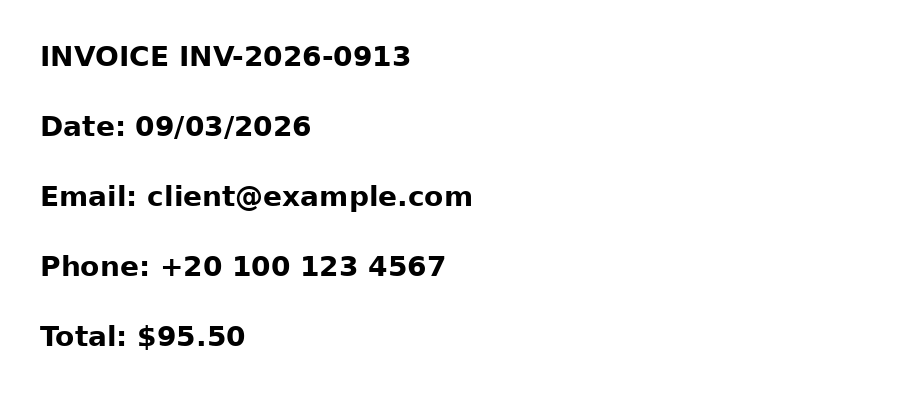


=== TESSERACT RESULT ===
{
  "pipeline": "tesseract",
  "document_type": "unknown",
  "raw_text": "INVOICE 'NV-2026.0913\n\nDate: 99/03/2026\nEmail: cHent@example.com\n\nPhone; +20 100 123 4567\nTotal: $95.50",
  "fields": {
    "dates": [
      "99/03/2026"
    ],
    "amounts": [
      95.5
    ],
    "emails": [
      "cHent@example.com"
    ],
    "phones": [
      "+20 100 123 4567"
    ],
    "document_ids": []
  },
  "processing_time_seconds": 1.294
}

=== QWEN2-VL RESULT ===
{
  "pipeline": "qwen2-vl",
  "document_type": "invoice",
  "raw_text": "```json\n{\n  \"document_type\": \"invoice\",\n  \"dates\": [\"09/03/2026\"],\n  \"amounts\": [\"95.50\"],\n  \"emails\": [\"client@example.com\"],\n  \"phones\": [\"+20 100 123 4567\"],\n  \"document_ids\": [],\n  \"summary\": \"Invoice for $95.50\"\n}\n```",
  "fields": {
    "dates": [
      "09/03/2026"
    ],
    "amounts": [
      "95.50"
    ],
    "emails": [
      "client@example.com"
    ],
    "phones": [
      "+20 100 123

In [9]:
import os
os.chdir("/content")

# 1) Fresh clone (always starts from /content, so re-running is always safe)
!rm -rf /content/document-ocr-structure-extraction
!git clone https://github.com/aidev-ahmedamr/document-ocr-structure-extraction.git
os.chdir("/content/document-ocr-structure-extraction")

!apt-get -qq install -y tesseract-ocr poppler-utils fonts-dejavu-core > /dev/null
!pip install -q -r requirements.txt

# 2) Verify the regex fix is actually there
print("=== Checking regex fix is present ===")
!grep -n "d{4,}" src/extraction/regex_extraction.py
print()

# 3) Build a CLEAN, high-quality test image (large bold font)
from PIL import Image, ImageDraw, ImageFont

img = Image.new("RGB", (900, 400), color="white")
draw = ImageDraw.Draw(img)

font_candidates = [
    "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
]
font = None
for path in font_candidates:
    if os.path.exists(path):
        font = ImageFont.truetype(path, 28)
        break
if font is None:
    font = ImageFont.load_default(size=28)

draw.text((40, 40), "INVOICE INV-2026-0913", fill="black", font=font)
draw.text((40, 110), "Date: 09/03/2026", fill="black", font=font)
draw.text((40, 180), "Email: client@example.com", fill="black", font=font)
draw.text((40, 250), "Phone: +20 100 123 4567", fill="black", font=font)
draw.text((40, 320), "Total: $95.50", fill="black", font=font)
img.save("sample_invoice.png")

print("=== Sample image created ===")
display(img)

# 4) Run Tesseract pipeline
from src.preprocessing.preprocess import preprocess_document
from src.ocr.tesseract_ocr import run_tesseract_multi_page
from src.extraction.regex_extraction import extract_fields
from src.extraction.compare import build_result, compare_results
import json

pages = preprocess_document("sample_invoice.png")
ocr_result = run_tesseract_multi_page(pages)
fields = extract_fields(ocr_result["text"])
tesseract_result = build_result("tesseract", ocr_result["text"], fields, ocr_result["processing_time_seconds"])

print("\n=== TESSERACT RESULT ===")
print(json.dumps(tesseract_result, indent=2))

# 5) Run Qwen2-VL pipeline
from src.ocr.vision_llm_ocr import run_vision_llm_multi_page

llm_result = run_vision_llm_multi_page(pages)
qwen_result = build_result(
    "qwen2-vl", llm_result["raw_text"], llm_result["fields"],
    llm_result["processing_time_seconds"], document_type=llm_result["document_type"]
)

print("\n=== QWEN2-VL RESULT ===")
print(json.dumps(qwen_result, indent=2))

# 6) Compare
report = compare_results(tesseract_result, qwen_result)
print("\n=== COMPARISON ===")
print(json.dumps(report, indent=2))

# 7) Tests
print("\n=== TESTS ===")
!python -m pytest tests/ -v

In [10]:
import os
os.chdir("/content")

# 1) Check raw file content DIRECTLY from GitHub's servers (bypasses git entirely)
print("=== RAW FILE FROM GITHUB (via curl, no git involved) ===")
!curl -s "https://raw.githubusercontent.com/aidev-ahmedamr/document-ocr-structure-extraction/main/src/extraction/regex_extraction.py" | grep -n "AMOUNT_PATTERN" -A 5

print()
print("=== Repo's default branch (via GitHub API) ===")
!curl -s "https://api.github.com/repos/aidev-ahmedamr/document-ocr-structure-extraction" | grep -i "default_branch"

print()
print("=== Fresh clone, explicitly on main ===")
!rm -rf /content/document-ocr-structure-extraction
!git clone -b main https://github.com/aidev-ahmedamr/document-ocr-structure-extraction.git
os.chdir("/content/document-ocr-structure-extraction")
!grep -n "AMOUNT_PATTERN" -A 5 src/extraction/regex_extraction.py

print()
print("=== Last commit info in the cloned repo ===")
!git log -1 --stat -- src/extraction/regex_extraction.py

=== RAW FILE FROM GITHUB (via curl, no git involved) ===
10:AMOUNT_PATTERN = (
11-    r'(?:(?:USD|EGP|\$|€|£)\s?(\d{1,3}(?:,\d{3})*(?:\.\d{2})?|\d{4,}(?:\.\d{2})?))'
12-    r'|'
13-    r'(?:(?:Total|Subtotal|Amount|Sum)\s*:?\s*(?:USD|EGP|\$|€|£)?\s*'
14-    r'(\d{1,3}(?:,\d{3})*(?:\.\d{2})?|\d{4,}(?:\.\d{2})?))'
15-)
--
32:    matches = re.findall(AMOUNT_PATTERN, text, re.IGNORECASE)
33-    amounts = []
34-    for group1, group2 in matches:
35-        raw = group1 or group2
36-        if not raw:
37-            continue

=== Repo's default branch (via GitHub API) ===
  "default_branch": "main",

=== Fresh clone, explicitly on main ===
Cloning into 'document-ocr-structure-extraction'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 100 (delta 40), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 34.07 KiB | 5.68 MiB/s, done.
Resolving deltas: 100% (40/40)